In [ ]:
from transformers import AutoModelForImageClassification, AutoProcessor
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt
import random
import numpy as np
import sys
import math

In [ ]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<function matplotlib.pyplot.show(close=None, block=None)>

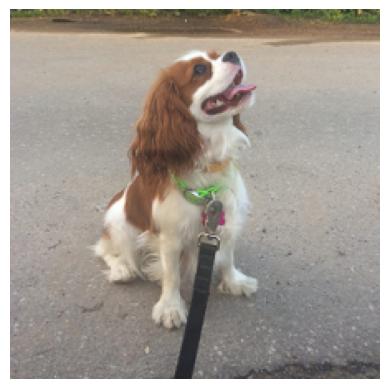

In [ ]:
image = Image.open("/content/sample_data/dog.jpg")

plt.imshow(image)
plt.axis("off")
plt.show

In [ ]:
from transformers import AutoImageProcessor

model_name = "hilmansw/resnet18-catdog-classifier"

model = AutoModelForImageClassification.from_pretrained(model_name).to(device)
model.eval()

# processor = AutoProcessor.from_pretrained(model_name)
# print(processor)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): Identity()
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                  (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (activation): ReLU()
           

In [ ]:
# Les Transforms

transformTensor = transforms.ToTensor()

transformPIL = transforms.ToPILImage()

transformIn = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  # -> je ne suis pas sûr de moi
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalisation -> ImageNet
])

transformOut = transforms.Compose([
    transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
    )
])

In [ ]:
def multiple_copies_generator(image, number_of_copies = 40):
    return image.unsqueeze(0).expand(number_of_copies, -1, -1, -1).to(device) # Format [number_of_copies, 3, x, y]

In [ ]:
# Genere aleatoirement les valeurs a ajouter sur chaque pixel

def noise_generator(multiple_copies, reach = 1, targeted = False, targeted_channel = 0): # reach = 0.1  ->  -0.1 <= x <= 0.1
                                                                                       # RGB -> 0-R; 1-G; 2-B

    batch_size, channels, height, width = multiple_copies.shape

    multiple_copies = multiple_copies.clone().to(device)  # Remove if modifying original is okay
    if targeted:
      # Create a tensor with the values to add (+ and -)
      values_to_change = torch.empty(batch_size, height, width).uniform_(-reach, reach).to(device)
      multiple_copies[:, targeted_channel, :, :] += values_to_change
    else:
      # Create a tensor with the values to add (+ and -)
      values_to_change = torch.empty(batch_size, channels, height, width).uniform_(-reach, reach).to(device)
      multiple_copies += values_to_change

    return multiple_copies.clamp_(0, 1)

In [ ]:
def parent_generator_fixed(multiple_copies):
    batch_size = multiple_copies.shape[0]
    parents_index = torch.randperm(batch_size, device=device) # shuffle the indexes

    return parents_index

In [ ]:
def crossover_generator(multiple_copies, parents_index, pourcentage_height = 0.15):
  multiple_copies_cross = multiple_copies.clone().to(device)

  batch_size, channels, height, width = multiple_copies.shape

  for i in range(0, len(parents_index), 2):
    parent_index_1 = parents_index[i]
    parent_index_2 = parents_index[i + 1]

    max_size_square = int(multiple_copies.shape[3] * pourcentage_height)  # % hauteur de l'image -> multiple_copies[0].shape[2] prend le nombre de pixel d'une image

    # Swaping zone setting
    which_channel = torch.randint(0, channels, (1,)).to(device)
    size_height = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_height = torch.randint(0, height - size_height + 1, (1,)).to(device)
    size_width = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_width = torch.randint(0, width - size_width + 1, (1,)).to(device)

    # Swaping
    swap_zone = multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width,].clone()

    multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = \
        multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width]

    multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = swap_zone

  return multiple_copies_cross

In [ ]:
def through_model(multiple_copies):
    # multiple_copies.shape -> (40, 3, 225, 224)
    batch_size = multiple_copies.shape[0]

    # One pic after the other, transformer don't handle 4D
    input_copies = torch.stack([transformIn(multiple_copies[i]).to(device) for i in range(batch_size)])

    with torch.no_grad():  # CNN inputs
        outputs = model(input_copies)

    processed_copies = transformOut(input_copies)

    logits = outputs.logits  # logits -> [40, num_classes]
    probabilities = torch.nn.functional.softmax(logits, dim=-1)

    return probabilities


In [ ]:
def selection(multiple_copies, probabilities, elites, wanted_class, unwanted_class, wanted=True):

    batch_size, channels, height, width = multiple_copies.shape

    probabilities_class = probabilities[:, wanted_class] if wanted else probabilities[:, unwanted_class]
    probabilities_class = probabilities_class.to(device)

    sorted_probabilities, indices = torch.sort(probabilities_class, descending=wanted)
    sorted_probabilities = sorted_probabilities.to(device)
    indices = indices.to(device)

    elites_index = indices[:elites]
    middle_index = indices[elites:batch_size//2]
    low_index = indices[batch_size//2:]

    elites_proba = sorted_probabilities[:elites]
    middle_proba = sorted_probabilities[elites:batch_size//2]
    low_proba = sorted_probabilities[batch_size//2:]

    elites_proba = elites_proba.float()
    middle_proba = middle_proba.float()
    low_proba = low_proba.float()

    elites_selection = multiple_copies[elites_index].to(device)
    middle_selection = multiple_copies[middle_index].to(device)
    low_selection = multiple_copies[low_index].to(device)

    #return elites_selection, middle_selection, low_selection, elites_index, elites_proba
    return elites_selection, middle_selection, elites_index, elites_proba

In [ ]:
def from_rgb_to_ycbcr(tensor_image):
    transform_matrix = torch.tensor([[0.299, 0.587, 0.114],
                                     [-0.169, -0.331, 0.499],
                                     [0.499, -0.460, -0.039]], device=device)

    tensor_image_ycbcr = torch.matmul(transform_matrix, tensor_image.view(3, -1)).to(device)

    # Reshape to have the original pytorch shape for images
    tensor_image_ycbcr = tensor_image_ycbcr.view(3, tensor_image.shape[1], tensor_image.shape[2])

    return tensor_image_ycbcr

In [ ]:
def checker(elites_index, elites_proba, threshold):

    # Search uniquely in elites
    for i in range(len(elites_proba)):
      if elites_proba[i] >= threshold:
        return True, elites_index[i]
      else:
        return False, -1

In [ ]:
# On appuie sur les bon pixels
# soucis stagnation

# NORMAL VERSION
# WITH ADDITIONAL NOISE -> ADS UP
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 10000

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

HEIGHT = 0.15 # significantly increse running time; its the height of the crossover square

REACH = 0.05 # value added to each pixel -> -REACH <= x <= REACH

ACCENTUATION = 1.1 # for + and -

# Control the overall noise -> needed because the noise become exponential
MIN_CLAMP = -0.05
MAX_CLAMP = 0.05

BATCH = 80
ELITES = int(BATCH/4)
SELECTION = ELITES # Can change with batch size

TARGETED = False
TARGETED_CHANNEL = 2

THRESHOLD = 0.51 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE
image = Image.open("/content/sample_data/dog.jpg")

tensor_image = transformTensor(image).to(device)
multiple_copies = multiple_copies_generator(tensor_image, BATCH)

base_copies = multiple_copies[:SELECTION]

multiple_copies = noise_generator(multiple_copies, reach=REACH, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 10 -> add noise
  noise_selection = noise_generator(base_copies, reach=REACH, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

  # 10 -> accentuate the differences
  random_indices = torch.randint(0, top_selection.shape[0], (SELECTION,))

  accentuate_selection = top_selection[random_indices]
  differencies_selection = base_copies - top_selection[random_indices]

  # 1ST WAY
  # To use the commented line below substract 1 to ACCENTUATION in the hyperparameters
  # Keep in mind that 0 is counted as a negative difference which is not a problem because with noise_generator() every pixels are concerned
  # So no pixel will have a 0 difference with the base image
  # Not the same with targeted channel as 2 channels will have no differencies but will be accentuated anyways!

  # differencies_selection = torch.where(differencies_selection > 0, differencies_selection + ACCENTUATION, differencies_selection - ACCENTUATION)

  # 2ND WAY
  # Good but too much saturation as the overall image is clamped

  # accentuate_selection = base_copies +  differencies_selection * ACCENTUATION
  # accentuate_selection = accentuate_selection.clamp(MIN_CLAMP, MAX_CLAMP) # Modify the clamp if needed

  # 3RD WAY
  # clamp() the difference to mitigate the overall saturation and search for good and aesthetic adversarial image

  differencies_selection = differencies_selection * ACCENTUATION
  differencies_selection = differencies_selection.clamp(MIN_CLAMP, MAX_CLAMP) # Modify the clamp if needed
  accentuate_selection = base_copies +  differencies_selection
  accentuate_selection = accentuate_selection.clamp(0, 1)

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 10 + 10 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection, accentuate_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]

    # 🥸 DISPLAY BEST IMAGE
    image_restored = transformPIL(adv_image)
    plt.imshow(image_restored)
    plt.axis("off")
    plt.show

    break

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
        1.5387e-06, 1.0804e-06, 1.0513e-06, 9.6386e-07, 6.5491e-07, 1.5849e-06,
        9.3007e-07, 6.7402e-07, 3.5650e-07, 6.2735e-07, 8.2674e-07, 3.4446e-06,
        5.5631e-06, 5.5393e-06, 4.1637e-06, 4.1637e-06, 1.3950e-06, 5.1665e-06,
        5.9771e-06, 4.0517e-07, 4.0517e-07, 4.9427e-06, 5.4581e-06, 8.8402e-07,
        4.0517e-07, 5.2882e-06, 5.1665e-06, 5.4581e-06, 4.0517e-07, 5.4040e-06,
        5.4581e-06, 4.0517e-07], device='cuda:0')
0.00038149673491716385
6619
tensor([2.6674e-05, 1.3676e-05, 1.0550e-05, 9.7085e-06, 8.8460e-06, 8.3182e-06,
        7.5082e-06, 7.2150e-06, 6.8461e-06, 7.7678e-06, 6.6759e-06, 6.6835e-06,
        6.6771e-06, 6.5496e-06, 6.5299e-06, 7.3666e-06, 5.8901e-06, 6.2833e-06,
        6.3799e-06, 6.3642e-06, 6.3204e-06, 6.3070e-06, 6.2310e-06, 6.1839e-06,
        6.1646e-06, 6.1503e-06, 6.0120e-06, 5.9612e-06, 5.2641e-06, 5.9826e-06,
        5.9678e-06, 5.8484e-06, 5.8058e-06, 

KeyboardInterrupt: 

In [ ]:
  # 😅 DISPLAY ELITES FOR MONITORING
  display_elites = [transformPIL(img) for img in elites_selection]

  fig, axes = plt.subplots(2, 5, figsize=(15, 6))

  for i, ax in enumerate(axes.flat):
      ax.imshow(display_elites[i])
      ax.axis("off")

  plt.show()